In [9]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [ ]:

card=pd.read_csv(r"C:\Users\saleh\OneDrive\Desktop\CAE-Intern\project\cleanData\clean_card.csv", sep=";")
card.head()

,card_id,disp_id,type,issued
0,1005,9285,classic,1993-11-07
1,104,588,classic,1994-01-19
2,747,4915,classic,1994-02-05
3,70,439,classic,1994-02-08
4,577,3687,classic,1994-02-15


C:\Users\saleh\AppData\Local\Temp\ipykernel_4744\3577686889.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


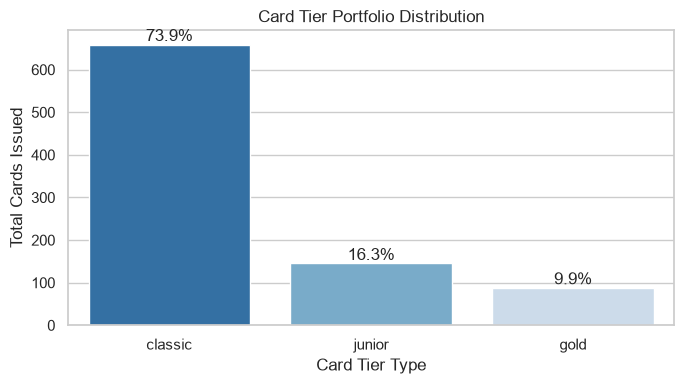

In [11]:
# 💳 Focused EDA & Feature Engineering Guide for `card` Table

# ---

## 1. High-Impact Exploratory Data Analysis (EDA)

# Since the `card` table contains credit/debit card issuances with temporal (`issued`), entity relation (`disp_id`), tier (`type`), and identity (`card_id`) features, the EDA should focus on adoption trends, portfolio tier distribution, and issuance velocity.

# ### A. Card Tier Distribution & Portfolio Composition
# Examines the proportion of standard versus premium card products (`classic`, `junior`, `gold`).

# ```python

plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=card,
    x="type",
    order=card["type"].value_counts().index,
    palette="Blues_r",
)
plt.title("Card Tier Portfolio Distribution")
plt.xlabel("Card Tier Type")
plt.ylabel("Total Cards Issued")

# Add percentage annotations
total = len(card)
for p in ax.patches:
  percentage = f"{100 * p.get_height() / total:.1f}%"
  ax.annotate(
      percentage,
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
  )

plt.tight_layout()
plt.show()

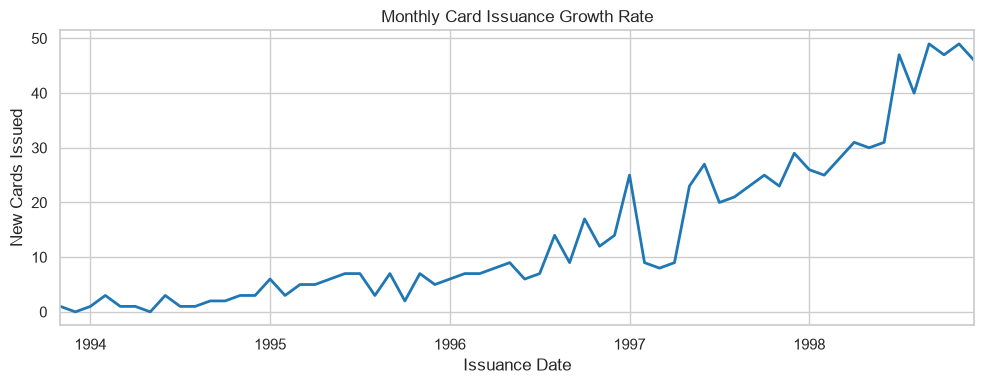

In [12]:
# Convert to datetime if not already done
card["issued"] = pd.to_datetime(card["issued"])

# Aggregate by month
card_monthly = card.set_index("issued").resample("ME")["card_id"].count()

plt.figure(figsize=(10, 4))
card_monthly.plot(color="#1f77b4", linewidth=2)
plt.title("Monthly Card Issuance Growth Rate")
plt.xlabel("Issuance Date")
plt.ylabel("New Cards Issued")
plt.tight_layout()
plt.show()

In [13]:
card.head()

,card_id,disp_id,type,issued
0,1005,9285,classic,1993-11-07
1,104,588,classic,1994-01-19
2,747,4915,classic,1994-02-05
3,70,439,classic,1994-02-08
4,577,3687,classic,1994-02-15
